# Game-Theoretic Shadow Field Engine v0.4
## Shadow Field Engine z teorią gier

Ten notebook rozbudowuje FIELD TENSION DYNAMICS o teorię gier: graczy, wypłaty, konflikt interesów, żal decyzyjny, stabilność gry oraz uproszczone scenariusze Nash-like.

In [1]:
from game_theoretic_shadow_field_engine import create_engine, report
import matplotlib.pyplot as plt

engine = create_engine()

## 1. Macierz agentów AI
Agenci technologiczni oceniają scenariusze z perspektywy ROI, ryzyka, strategii, etyki, danych i organizacji.

In [2]:
engine.agent_matrix().round(2)

,scenario,ROI_AGENT,RISK_AGENT,STRATEGY_AGENT,ETHICS_AGENT,DATA_AGENT,ORG_AGENT
0,AI Knowledge Graph,7.55,2.00,10.00,9.10,8.22,8.85
1,Predictive Maintenance,8.90,2.80,9.50,7.85,8.60,7.15
2,AI Quality Control,8.30,4.43,9.90,7.00,7.07,6.42
3,Customer Service Agent,6.65,3.90,7.85,6.70,7.40,7.40
4,Financial Forecasting Agent,7.60,5.55,8.80,6.25,6.42,5.75
5,Autonomous Decision Cockpit,9.20,7.02,10.00,6.40,6.10,5.18
6,HR Competence Mapper,5.70,3.10,7.90,7.95,5.93,9.10
7,Logistics Optimization AI,8.30,3.30,8.95,7.75,7.52,7.10


## 2. Macierz wypłat graczy
Gracze reprezentują interesariuszy: BOARD, IT, EMPLOYEES, CUSTOMERS, CFO. Każdy ma własną funkcję użyteczności.

In [3]:
payoff = engine.payoff_matrix()
payoff.round(3)

,scenario,BOARD,IT,EMPLOYEES,CUSTOMERS,CFO,social_welfare,conflict,min_payoff,max_payoff
0,AI Knowledge Graph,5.875,5.100,4.725,4.150,4.825,4.935,0.563,4.150,5.875
1,Predictive Maintenance,5.825,4.625,3.725,3.725,5.225,4.625,0.827,3.725,5.825
2,AI Quality Control,5.550,3.675,3.000,3.175,4.575,3.995,0.951,3.000,5.550
3,Customer Service Agent,4.500,3.925,3.300,2.800,3.675,3.640,0.573,2.800,4.500
4,Financial Forecasting Agent,4.825,2.975,2.400,2.600,3.850,3.330,0.898,2.400,4.825
5,Autonomous Decision Cockpit,5.950,2.675,2.025,2.850,4.600,3.620,1.444,2.025,5.950
6,HR Competence Mapper,4.375,3.900,4.300,3.000,3.200,3.755,0.562,3.000,4.375
7,Logistics Optimization AI,5.400,4.075,3.600,3.425,4.675,4.235,0.726,3.425,5.400


## 3. Regret matrix
Żal decyzyjny pokazuje, ile każdy gracz traci względem swojego najlepszego możliwego scenariusza.

In [4]:
regret = engine.regret_matrix()
regret.head(20).round(3)

,player,scenario,payoff,best_possible,regret
0,BOARD,AI Knowledge Graph,5.875,5.950,0.075
1,BOARD,Predictive Maintenance,5.825,5.950,0.125
2,BOARD,AI Quality Control,5.550,5.950,0.400
3,BOARD,Customer Service Agent,4.500,5.950,1.450
4,BOARD,Financial Forecasting Agent,4.825,5.950,1.125
5,BOARD,Autonomous Decision Cockpit,5.950,5.950,0.000
6,BOARD,HR Competence Mapper,4.375,5.950,1.575
7,BOARD,Logistics Optimization AI,5.400,5.950,0.550
8,IT,AI Knowledge Graph,5.100,5.100,0.000
9,IT,Predictive Maintenance,4.625,5.100,0.475


## 4. Stabilność gry
Scenariusz jest stabilny, jeśli żaden gracz nie ma silnej motywacji do odejścia od tej decyzji. To uproszczona wersja intuicji równowagi Nasha.

In [5]:
engine.game_stability().round(3)

,scenario,max_regret,avg_regret,game_stability
0,AI Knowledge Graph,0.400,0.095,0.714
1,Predictive Maintenance,1.000,0.405,0.500
2,AI Quality Control,1.725,1.035,0.367
3,Customer Service Agent,1.550,1.390,0.392
4,Financial Forecasting Agent,2.325,1.700,0.301
5,Autonomous Decision Cockpit,2.700,1.410,0.270
6,HR Competence Mapper,2.025,1.275,0.331
7,Logistics Optimization AI,1.125,0.795,0.471


## 5. Scenariusze Nash-like
To nie jest ścisła równowaga Nasha w pełnej grze strategicznej, ale dydaktyczna heurystyka: nikt nie ma dużego regret.

In [6]:
engine.find_pure_nash_like_scenarios(regret_threshold=0.75).round(3)

,scenario,max_regret,avg_regret,game_stability
0,AI Knowledge Graph,0.4,0.095,0.714


## 6. Pole decyzji z teorią gier
Energia pola uwzględnia teraz nie tylko AI i napięcia, ale też social welfare, konflikt interesariuszy, game stability i max regret.

In [7]:
selected, shadows, field = engine.collapse(temperature=1.4)
field[['scenario','probability','energy','field_tension','social_welfare','stakeholder_conflict','game_stability','max_regret','instability']].round(3)

,scenario,probability,energy,field_tension,social_welfare,stakeholder_conflict,game_stability,max_regret,instability
0,AI Knowledge Graph,0.388,7.843,2.924,4.935,0.563,0.714,0.400,3.886
1,Predictive Maintenance,0.205,6.949,3.602,4.625,0.827,0.500,1.000,5.430
2,Logistics Optimization AI,0.123,6.233,2.716,4.235,0.726,0.471,1.125,4.567
3,AI Quality Control,0.082,5.673,2.776,3.995,0.951,0.367,1.725,5.452
4,Customer Service Agent,0.059,5.208,1.583,3.640,0.573,0.392,1.550,3.706
5,HR Competence Mapper,0.053,5.064,1.979,3.755,0.562,0.331,2.025,4.566
6,Autonomous Decision Cockpit,0.047,4.879,2.290,3.620,1.444,0.270,2.700,8.909
7,Financial Forecasting Agent,0.044,4.788,1.856,3.330,0.898,0.301,2.325,5.079


## 7. Raport collapse

In [8]:
print(report(selected, shadows))

GAME-THEORETIC SHADOW FIELD ENGINE — DECISION REPORT\n======================================================================\nCOLLAPSED DECISION: AI Knowledge Graph\nProbability: 0.388\nEnergy: 7.843\nField tension: 2.924\nGame stability: 0.714\nStakeholder conflict: 0.563\nMax regret: 0.400\nInstability: 3.886\n\nInterpretation:\nThe selected decision is not only strong in the AI field. It is also relatively stable in the stakeholder game.\nThe system rewards high social welfare and game stability, while penalizing conflict and regret.\n\nSHADOW ALTERNATIVES:\n- Predictive Maintenance | p=0.205, energy=6.949, game_stability=0.500, conflict=0.827\n- Logistics Optimization AI | p=0.123, energy=6.233, game_stability=0.471, conflict=0.726\n- AI Quality Control | p=0.082, energy=5.673, game_stability=0.367, conflict=0.951\n\nCore thesis:\nA decision is not merely optimal. It must survive the strategic field of players, incentives, conflicts and regret.


## 8. Mapa: energia vs konflikt interesariuszy

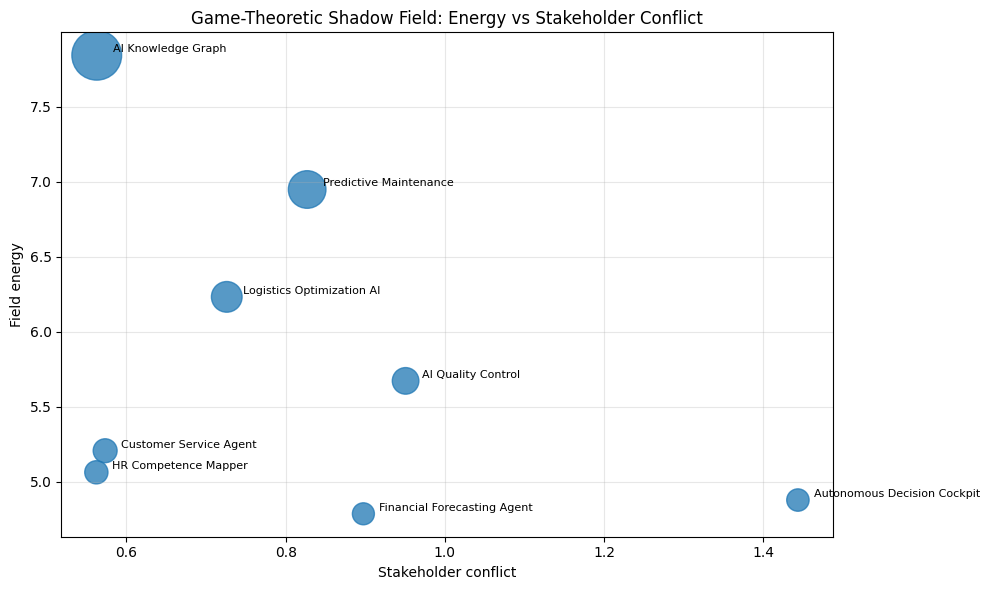

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(field["stakeholder_conflict"], field["energy"], s=field["probability"] * 3000 + 120, alpha=0.75)
for _, row in field.iterrows():
    plt.text(row["stakeholder_conflict"] + 0.02, row["energy"] + 0.02, row["scenario"], fontsize=8)
plt.title("Game-Theoretic Shadow Field: Energy vs Stakeholder Conflict")
plt.xlabel("Stakeholder conflict")
plt.ylabel("Field energy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Mapa: napięcie pola vs stabilność gry

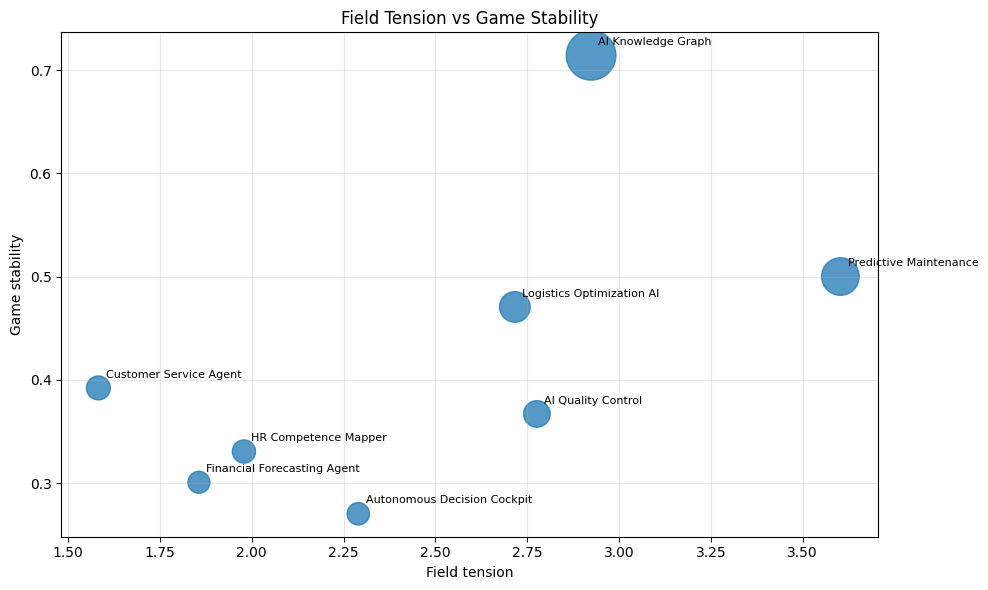

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(field["field_tension"], field["game_stability"], s=field["probability"] * 3000 + 120, alpha=0.75)
for _, row in field.iterrows():
    plt.text(row["field_tension"] + 0.02, row["game_stability"] + 0.01, row["scenario"], fontsize=8)
plt.title("Field Tension vs Game Stability")
plt.xlabel("Field tension")
plt.ylabel("Game stability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Timeline: pamięć pola + teoria gier
Po każdym collapse system zostawia semantyczny ślad. Kolejne decyzje są deformowane przez pamięć oraz pole interesów.

In [12]:
timeline = engine.timeline(rounds=6, temperature=1.4)
timeline.round(3)

,round,selected,probability,energy,field_tension,game_stability,stakeholder_conflict,semantic_gravity
0,1,AI Knowledge Graph,0.429,8.143,2.924,0.714,0.563,1.0
1,2,AI Knowledge Graph,0.471,8.443,2.924,0.714,0.563,2.0
2,3,AI Knowledge Graph,0.514,8.743,2.924,0.714,0.563,3.0
3,4,AI Knowledge Graph,0.556,9.043,2.924,0.714,0.563,4.0
4,5,AI Knowledge Graph,0.597,9.343,2.924,0.714,0.563,5.0
5,6,AI Knowledge Graph,0.636,9.643,2.924,0.714,0.563,6.0


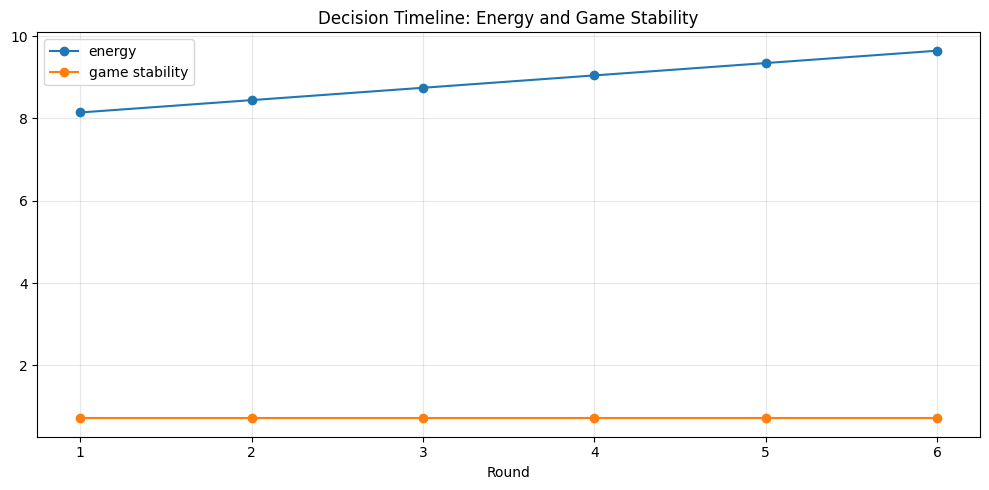

In [13]:
plt.figure(figsize=(10,5))
plt.plot(timeline["round"], timeline["energy"], marker="o", label="energy")
plt.plot(timeline["round"], timeline["game_stability"], marker="o", label="game stability")
plt.title("Decision Timeline: Energy and Game Stability")
plt.xlabel("Round")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Zadania dla studentów
1. Dodaj nowego gracza: REGULATOR.
2. Dodaj nowy scenariusz: AI Governance Layer.
3. Zwiększ wagę konfliktu interesariuszy w funkcji energii.
4. Sprawdź, czy collapse przesunie się w stronę bardziej stabilnych scenariuszy.
5. Porównaj wynik systemu bez teorii gier i z teorią gier.